# A Probabilistic U-Net with a post-hoc consensus-selection head

**Medical Images Processing with Deep Learning (336033) — submission notebook**

A PyTorch reimplementation of Kohl et al., *A Probabilistic U-Net for Segmentation of
Ambiguous Images* (NeurIPS 2018, [arXiv:1806.05034](https://arxiv.org/abs/1806.05034)),
trained on LIDC-IDRI, extended in two independent directions:

| phase | what it is | status |
|---|---|---|
| **1** | faithful reproduction — architecture, augmentation, 5-step LR decay, the paper's iteration budget | reference for everything below |
| **2** | modernization — one flag: a **full-covariance** latent Gaussian instead of the paper's axis-aligned one | outcome confirmed, **mechanism refuted** |
| **3** | extension — a **post-hoc consensus-selection head** that picks one sample from many, without ground truth | the graded contribution |

---

## How to read this notebook: two independent tiers

They share the library and **never share outputs**.

**Tier 1 — the reported results (sections 0–6).** Renders precomputed arrays with `numpy`,
`matplotlib` and `json` only. Loads **no model**, runs **no inference**, needs **no
weights**. Every figure comes from `data/processed/showcase.npz` and `results/*.json`,
both tracked in the repository.

**Tier 2 — the executability demo (section 7).** Trains a deliberately undersized model
from scratch on a tracked 288-patch subset, prints a loss curve, samples a few masks, and
**discards the weights**. It reports nothing. It exists to show the pipeline runs
end-to-end inside Colab.

Section 8 runs the test suite.

> **No `pip install` anywhere in this notebook.** `torch`, `numpy`, `matplotlib` and
> `scipy` are all preinstalled in Colab, and installing anything is the most common way a
> grader's run breaks.

In [1]:
# ── BOOTSTRAP ────────────────────────────────────────────────────────────────────────
# Works both from the Colab badge (clones) and from an unzipped submission (already on
# disk). No pip install: torch, numpy, matplotlib and scipy are preinstalled in Colab,
# and installing anything is the most common way a grader's run breaks.
#
# Written without helper functions on purpose: this cell runs BEFORE src/ is importable,
# and the repository's own test asserts that no notebook cell defines one.

# The tag to clone when the repo is not already on disk.
# NOTE: `submission-v1` does not exist yet -- it is created at submission time. Until
# then this must stay on the default branch. Switching it is this one line.
REPO_REF = "main"          # <- change to "submission-v1" once that tag is pushed
REPO_URL = "https://github.com/RanWeisberg/prob-unet-consensus-selection.git"

import os, subprocess, sys
from pathlib import Path

MARKERS = ("pyproject.toml", "data/processed/showcase.npz")

here = Path.cwd().resolve()
candidates = [here, *here.parents,
              Path("/content/prob-unet-consensus-selection"),
              here / "prob-unet-consensus-selection"]
searched, ROOT = [], None
for candidate in candidates:
    searched.append(candidate)
    if all((candidate / marker).exists() for marker in MARKERS):
        ROOT = candidate
        break

if ROOT is None:
    target = (Path("/content") if Path("/content").is_dir() else here)
    target = target / "prob-unet-consensus-selection"
    print(f"repository not on disk; cloning {REPO_REF} into {target}")
    subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", REPO_REF, REPO_URL, str(target)],
        check=True,
    )
    searched.append(target)
    if all((target / marker).exists() for marker in MARKERS):
        ROOT = target

if ROOT is None:
    raise FileNotFoundError(
        "could not locate the repository root. A root must contain ALL of "
        f"{MARKERS}.\nSearched:\n  " + "\n  ".join(str(p) for p in searched)
    )

os.chdir(ROOT)                      # configs/ and scripts/ use repo-root-relative paths
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
assert all((ROOT / marker).exists() for marker in MARKERS), f"markers vanished: {MARKERS}"

import torch
print(f"repo root  : {ROOT}")
print(f"python     : {sys.version.split()[0]}")
print(f"torch      : {torch.__version__}")
print(f"markers    : all present ({', '.join(MARKERS)})")

repo root  : /Users/ranweisberg/PycharmProjects/Medical Images Analysis with Deep Learning/prob-unet-consensus-selection
python     : 3.12.7
torch      : 2.7.1
markers    : all present (pyproject.toml, data/processed/showcase.npz)


## Split discipline — read this once, it labels everything below

> # THE TEST SPLIT IS THE RESULTS SPLIT. VALIDATION IS THE DEVELOPMENT RECORD.
>
> The test split was evaluated **once**, after the scoring target, the head
> hyperparameters, the denominators and every threshold had been frozen. Validation drove
> every decision and is therefore reported as a development record, never as a result.

Every table and figure below carries a `TEST` or `VAL` label. Three quantities exist
**only** on validation by construction, and are labelled `VAL` wherever they appear:

1. the **effective-rank mechanism refutation** (§3) — the latent-geometry diagnostic was
   run on the validation split;
2. the **selection-on-validation optimism** estimate (§6, DEVIATIONS 14) — it is measured
   from the validation monitor curve, so it cannot exist on test;
3. the **miscalibrated pre-registered band** for the head (§6) — a pre-registration made
   before test was touched.

None of those is relabelled as test anywhere in this notebook.

## Why the results are precomputed rather than recomputed here

The reported numbers were produced once, on the training hardware, by the scripts in
`scripts/`. This notebook **renders those same recorded predictions and measures nothing
new**. That is a deliberate choice, not a convenience:

- Seeds do not reproduce across backends. The recorded candidates were drawn on CUDA with
  a fixed CPU generator; sampling live on a Colab CPU or T4 would produce *different*
  candidates, and every table here would drift from the tracked JSONs it is supposed to
  reproduce.
- Full-length training is a multi-day job (§0) and cannot run inside a Colab session.

To make that trustworthy rather than merely stated, `scripts/export_showcase.py`
recomputed the full aggregate tables through the published code path and asserted, figure
by figure and with **no tolerance**, that they reproduce the published JSONs exactly. The
next cell prints that verification list out of the export's own manifest rather than
asserting it in prose.

In [2]:
# ── TIER 1 LIBRARY ───────────────────────────────────────────────────────────────────
# Every helper lives in the package (src/probunet/notebook.py); cells carry explanation
# and a call. numpy + matplotlib + json + pathlib only -- nothing whose version could
# differ between this machine and a grader's Colab.
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from probunet.notebook import (
    PALETTE as CLR, RC_PARAMS, case_arrays, consensus_panel, crop_box,
    describe_monotonicity, load_manifest, load_results, mask_areas, panel,
    phase2_case_figure, selection_case_figure, stat as val, table,
)

plt.rcParams.update(RC_PARAMS)

RESULTS = ROOT / "results"
SHOW = np.load(ROOT / "data" / "processed" / "showcase.npz", allow_pickle=False)
MAN = load_manifest(SHOW)
res = lambda name: load_results(RESULTS, name)      # noqa: E731 -- a binding, not logic
case = lambda prefix: case_arrays(SHOW, prefix)     # noqa: E731

print(f"showcase.npz : {len(SHOW.files)} arrays, "
      f"{(ROOT / 'data/processed/showcase.npz').stat().st_size / 1024**2:.2f} MiB")
print(f"results/     : {len(sorted(RESULTS.glob('*.json')))} tracked JSON files")
print(f"helpers      : probunet.notebook (no logic in cells -- asserted by the test "
      f"suite)")

showcase.npz : 90 arrays, 0.45 MiB
results/     : 18 tracked JSON files
helpers      : probunet.notebook (no logic in cells -- asserted by the test suite)


In [3]:
# The export verified itself against the published JSONs. Printed, not asserted in prose.
print("EXPORT VERIFICATION — recomputed through the published code path, exact match "
      "required (no tolerance)\n")
for a in MAN["assertions"]:
    what = ("figures " + ", ".join(a["figures"]) if "figures" in a
            else "GED @ " + ", ".join(str(n) for n in a["sample_counts"])
                 + " (" + ", ".join(a["statistics"]) + ")")
    scope = " x buckets " + ", ".join(a["buckets"]) if "buckets" in a else ""
    print(f"  [{'MATCHED' if a['matched'] else 'FAILED '}]  {a['source']}")
    print(f"             {what}{scope}")
print(f"\nAll four published results files reproduced exactly. "
      f"Export git revision {MAN['export_git_revision']}, "
      f"generated {MAN['generated_at'][:19]} UTC.")

EXPORT VERIFICATION — recomputed through the published code path, exact match required (no tolerance)

  [MATCHED]  results\consensus_selection_test.json
             figures random, area, head, oracle, ceil, edge x buckets 1 grader, 2 graders, 3 graders, 4 graders, all
  [MATCHED]  results\consensus_selection_modernized_test.json
             figures random, area, head, oracle, ceil, edge x buckets 1 grader, 2 graders, 3 graders, 4 graders, all
  [MATCHED]  results\evaluation_test_baseline-short.json
             GED @ 1, 4, 8, 16 (mean, median, std)
  [MATCHED]  results\evaluation_test_modernized-short.json
             GED @ 1, 4, 8, 16 (mean, median, std)

All four published results files reproduced exactly. Export git revision 1e116e8, generated 2026-08-11T07:03:18 UTC.


---
# 0. Provenance and the cast of runs

**Full-length training ran on a local RTX 3070 Ti (8 GiB), on Windows.** It is a multi-day
job and is not reproducible inside a Colab session — which is exactly why Tier 1 renders
recorded predictions and Tier 2 (§7) is the Colab-executable path.

**Why there are two Phase 1 arms.** `baseline` is the full-length Phase 1 run at the
paper's Appendix H.1 budget; it is the **frozen base** the selection head is trained on, so
it carries the Phase 3 result. `baseline-short` is a shorter run that exists solely as the
**matched-pair control** for Phase 2: it and `modernized-short` share budget, schedule,
split, seed and batch size and differ in exactly one config line
(`model.latent_covariance`), so the Phase 2 comparison isolates that one flag. Comparing
`modernized-short` against the full-length `baseline` would confound the covariance change
with a budget change.

In [4]:
# The cast, built entirely from showcase.npz's manifest.
rows = []
for name, v in MAN["variants"].items():
    rows.append([
        name,
        v["checkpoint"].replace("\\", "/"),
        v["epoch"],
        v["checkpoint_git_revision"],
        v["latent_covariance"],
        f'{v["parameter_count"]:,}',
        (v["base_parameter_sha256"] or "—")[:12],
        (v["base_checkpoint"] or "—").replace("\\", "/"),
    ])
table(["run", "checkpoint", "best ep", "git SHA", "latent", "params",
       "base sha256", "frozen base"], rows,
      title="THE CAST — every checkpoint behind a number in this notebook")

print()
table(["field", "value"], [
    ["split", MAN["split"] + "   <- THE RESULTS SPLIT"],
    ["patches", f'{MAN["n_patches"]:,}'],
    ["eval seed", MAN["eval_seed"]],
    ["samples / image", MAN["n_samples"]],
    ["GED sample counts", ", ".join(str(n) for n in MAN["ged_sample_counts"])],
    ["torch", MAN["torch_version"]],
    ["device", MAN["device"]],
    ["platform", MAN["environment"]["platform"]],
    ["export git SHA", MAN["export_git_revision"]],
    ["exported", MAN["generated_at"][:19] + " UTC"],
], title="EVALUATION ENVIRONMENT")

print("\nThe full-length Phase 1 run appears only as the head's frozen base: its identity "
      "is\nverified by the sha256 of its parameter values, not by its filename.")

THE CAST — every checkpoint behind a number in this notebook
run                        checkpoint                                          best ep  git SHA        latent    params      base sha256   frozen base                              
-------------------------  --------------------------------------------------  -------  -------------  --------  ----------  ------------  -----------------------------------------
baseline_short                        runs/baseline-short/checkpoints/best.pt       57        2c0a4ec  diagonal  27,499,098             —                                          —
modernized_short                    runs/modernized-short/checkpoints/best.pt       50  31a50e6-dirty      full  27,514,488             —                                          —
selection_head                        runs/selection-head/checkpoints/best.pt       29        023fb5b  diagonal  27,617,724  b1887d8d242f          runs/baseline/checkpoints/best.pt
selection_head_modernized  runs/se

---
# 1. The problem: there is no single ground truth

Each LIDC patch carries **four independent expert annotations**, and they disagree. A
grader may see no lesion at all: up to three of the four masks can be empty, and that is
signal, not noise.

**Ambiguity buckets.** Every table below is stratified by the **number of non-empty grader
masks** (1–4). Bucket 1 means one radiologist saw a lesion and three saw nothing — maximum
disagreement about *existence*. Bucket 4 means all four saw one — disagreement is about
*extent* only. The two regimes behave completely differently, and an aggregate that mixes
them hides the interesting part.

**Soft consensus** is the equal-weighted average of the four masks, so every pixel takes a
value in {0, 0.25, 0.5, 0.75, 1} — *the fraction of graders who included it*. This is the
Phase 3 selection target, and **only** that: GED and every other distribution metric keep
the four masks separate, because collapsing them would destroy exactly the grader spread
Phase 1 exists to measure.

Equal weighting is an **explicit assumption**: LIDC's annotators are anonymous and carry no
identity across patches, so per-grader reliability cannot be estimated from this data.

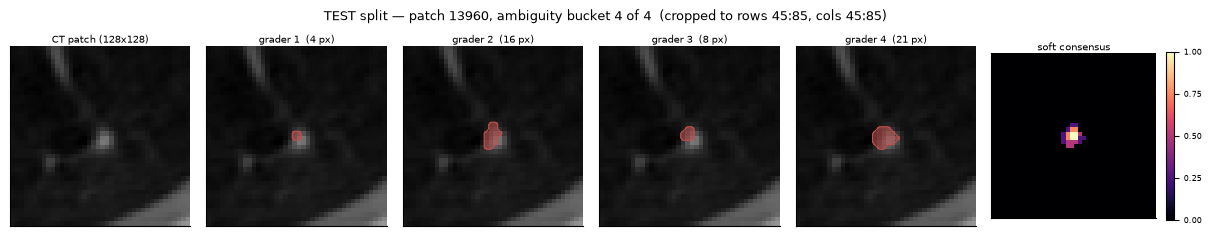

grader areas (px)      : [4, 16, 8, 21]
consensus levels present: [0.0, 0.25, 0.5, 0.75, 1.0]
achievable ceiling here : 0.7619  (the best score ANY binary mask could reach against this soft target)


In [5]:
c = case("b2")            # bucket 4: all four graders saw a lesion, so all five consensus
box = crop_box([c["masks"]], margin=16)   # levels can appear
fig, axes = plt.subplots(1, 6, figsize=(12.2, 2.35))

panel(axes[0], c["image"], box=box, title="CT patch (128x128)")
for i in range(4):
    area = int(c["masks"][i].sum())
    panel(axes[i + 1], c["image"], c["masks"][i], box=box, colour=CLR["grader"],
          title=f"grader {i + 1}  ({area} px)")

r0, r1, c0, c1 = box
cb = fig.colorbar(consensus_panel(axes[5], c["consensus"], box), ax=axes[5],
                  fraction=0.046, ticks=[0, .25, .5, .75, 1])
cb.ax.tick_params(labelsize=6)

fig.suptitle(f"TEST split — patch {int(c['patch_index'])}, ambiguity bucket "
             f"{int(c['bucket'])} of 4  (cropped to rows {r0}:{r1}, cols {c0}:{c1})",
             fontsize=9)
fig.tight_layout(); plt.show()

print(f"grader areas (px)      : {[int(m.sum()) for m in c['masks']]}")
print(f"consensus levels present: "
      f"{sorted(round(float(x), 2) for x in np.unique(c['consensus']))}")
print(f"achievable ceiling here : {float(c['ceiling']):.4f}  "
      f"(the best score ANY binary mask could reach against this soft target)")

### Scores are bounded well below 1 — by construction

The candidate is a hard 0/1 mask; the target is soft. A *perfect* mask on a bucket-1 patch
cannot score 1.0, because three quarters of the consensus mass is missing from a target only
one grader contributed to.

**Every soft-consensus number in §4 must be read against its ceiling or against the oracle,
never against 1.0.** The ceiling is printed beside the scores everywhere it appears; the
measured per-bucket ceilings are below.

In [6]:
ceil_rows = res("consensus_selection_test.json")["buckets"]
table(["ambiguity bucket", "patches", "achievable ceiling"],
      [[k, f'{ceil_rows[k]["n"]:,}', f'{val(ceil_rows[k], "ceiling"):.4f}']
       for k in ceil_rows],
      title="TEST split — the best score ANY binary mask could reach, per bucket",
      note="\nRead every soft-consensus number in section 4 against these, never "
           "against 1.0.")

TEST split — the best score ANY binary mask could reach, per bucket
ambiguity bucket  patches  achievable ceiling
----------------  -------  ------------------
1 grader              992              0.4000
2 graders             551              0.5833
3 graders             525              0.7347
4 graders             951              0.8878
all                 3,019              0.6453

Read every soft-consensus number in section 4 against these, never against 1.0.


---
# 2. Phase 1 — the reproduction

A faithful reimplementation of Appendix H.1: 4 down / 4 up sampling steps, three 3x3 convs
per scale, 32 base channels, a 6-dimensional latent broadcast and concatenated to the
**last** U-Net activation, `f_comb` as three 1x1 convolutions, average-pool down and
bilinear up, He-normal init. The paper's augmentation, its five-step learning-rate decay
and its iteration budget are all reproduced; departures are itemised in `DEVIATIONS.md`.

The architecture's efficiency claim is real and is what makes the extension cheap: drawing
*m* samples for one image re-runs only `f_comb`, not the U-Net.

Below: 16 prior samples from the **full-length Phase 1 baseline**, drawn for one test
patch. These are the recorded candidates the selection head in §4 chooses among.

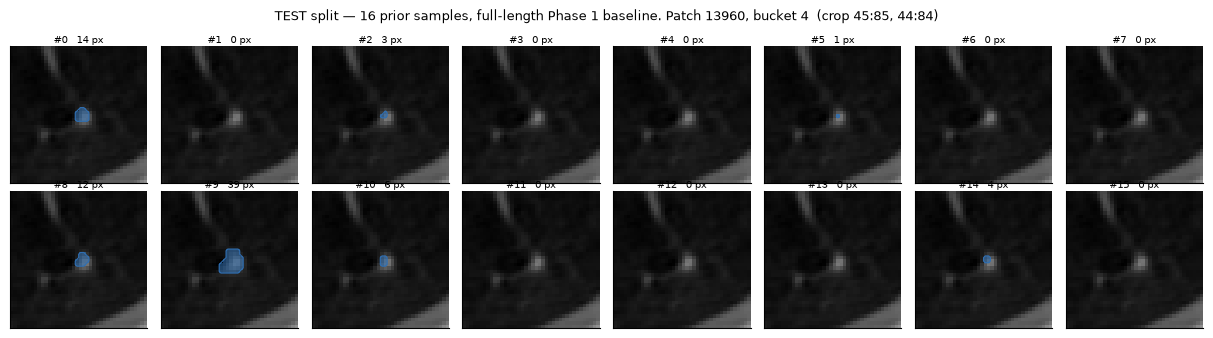

non-empty samples : 7 of 16
grader areas (px) : [4, 16, 8, 21]
The model expresses 'maybe there is nothing here' by emitting empty masks -- that is
the lesion-existence ambiguity of bucket 1-3 patches, not a failure.


In [7]:
c = case("b2")
cand = c["candidates"]
box = crop_box([c["masks"], cand], margin=10)
areas = mask_areas(cand)

fig, axes = plt.subplots(2, 8, figsize=(12.2, 3.4))
for i, ax in enumerate(axes.ravel()):
    panel(ax, c["image"], cand[i], box=box, colour=CLR["head"],
          title=f"#{i}   {int(areas[i])} px")
r0, r1, c0, c1 = box
fig.suptitle(f"TEST split — 16 prior samples, full-length Phase 1 baseline. "
             f"Patch {int(c['patch_index'])}, bucket {int(c['bucket'])}  "
             f"(crop {r0}:{r1}, {c0}:{c1})", fontsize=9)
fig.tight_layout(); plt.show()

print(f"non-empty samples : {int((areas > 0).sum())} of {len(areas)}")
print(f"grader areas (px) : {[int(m.sum()) for m in c['masks']]}")
print("The model expresses 'maybe there is nothing here' by emitting empty masks -- that "
      "is\nthe lesion-existence ambiguity of bucket 1-3 patches, not a failure.")

In [8]:
b = res("evaluation_test_baseline.json")
agg = b["aggregate_over_all_patches"]
counts = b["sample_counts"]

table(["n samples", "GED^2", "median", "IQR"],
      [[n, f'{val(agg, f"ged@{n}"):.4f}', f'{val(agg, f"ged@{n}", "median"):.4f}',
        f'{val(agg, f"ged@{n}", "iqr"):.4f}'] for n in counts],
      title="TEST split — full-length Phase 1 baseline: GED^2 by sample count "
            "(lower is better)")

n = counts[-1]
print()
table(["quantity", "value"], [
    [f"patches", f'{agg["n_patches"]:,}'],
    [f"median lesion area", f'{agg["lesion_area_median_px"]:.0f} px'],
    [f"random-sample Dice @{n}", f'{val(agg, f"random_sample_dice@{n}"):.4f}'],
    [f"oracle Dice @{n}", f'{val(agg, f"oracle_dice@{n}"):.4f}'],
    [f"per-grader oracle Dice @{n}", f'{val(agg, f"oracle_dice_per_grader@{n}"):.4f}'],
    [f"Hungarian-matched IoU @{n}", f'{val(agg, f"hungarian_iou@{n}"):.4f}'],
    [f"all-empty predictor GED^2", f'{val(agg, "empty_ged"):.4f}'],
], title="TEST split — single-sample quality and the degenerate baseline")

print("\nGED^2 decreases monotonically with more samples, which is the qualitative claim "
      "the\npaper's Figure 4a supports. The all-empty predictor is printed so the GED "
      "numbers can\nbe read against a predictor that models no ambiguity at all.")

TEST split — full-length Phase 1 baseline: GED^2 by sample count (lower is better)
n samples  GED^2   median  IQR   
---------  ------  ------  ------
1          0.7523  0.5400  1.0907
4          0.4062  0.2519  0.3907
8          0.3498  0.2161  0.3338
16         0.3211  0.1899  0.3280

TEST split — single-sample quality and the degenerate baseline
quantity                    value 
--------------------------  ------
patches                      3,019
median lesion area           43 px
random-sample Dice @16      0.4621
oracle Dice @16             0.6857
per-grader oracle Dice @16  0.8395
Hungarian-matched IoU @16   0.7635
all-empty predictor GED^2   0.8482

GED^2 decreases monotonically with more samples, which is the qualitative claim the
paper's Figure 4a supports. The all-empty predictor is printed so the GED numbers can
be read against a predictor that models no ambiguity at all.


> **The paper reports no LIDC GED number** — Table 2 is Cityscapes, and LIDC appears only
> as a scatter plot (Fig. 4a). So there is nothing here to reproduce numerically. The
> external anchor used instead is Bhat et al., *Generalized Probabilistic U-Net*
> ([arXiv:2207.12872](https://arxiv.org/abs/2207.12872)), which trains on the same
> preprocessed LIDC data with a near-identical split — cited in §3 as a **sanity range**,
> not a reproduction target.

---
# 3. Phase 2 — a full-covariance latent

The paper's prior and posterior both emit an **axis-aligned** Gaussian, forcing the six
latent dimensions to be mutually independent. Phase 2 replaces that with a **full
covariance** parameterised by its Cholesky factor `L`, so `Σ = L Lᵀ` is positive-definite
by construction and the latent dimensions can correlate. It arrives behind a single config
flag; the semantic diff between `baseline.yaml` and `modernized.yaml` is two lines.

The motivation was that graders do not disagree in independent per-dimension wiggles — when
a boundary is ambiguous, several aspects of the shape shift together — so the change targets
GED directly rather than by side effect.

**Three things have to land here, and the third is the one that matters.**

In [9]:
comp = res("comparison_test.json")
arms = ["baseline-short", "modernized-short"]
A = {a: comp["variants"][a]["aggregate_over_all_patches"] for a in arms}
N = comp["sample_counts"][-1]

g0, g1 = val(A[arms[0]], f"ged@{N}"), val(A[arms[1]], f"ged@{N}")
delta_pct = 100.0 * (g1 - g0) / g0

table(["arm", "latent", f"GED^2 @{N}", "median", "n"],
      [[a, MAN["variants"][a.replace("-", "_")]["latent_covariance"],
        f'{val(A[a], f"ged@{N}"):.4f}', f'{val(A[a], f"ged@{N}", "median"):.4f}',
        f'{A[a]["n_patches"]:,}'] for a in arms],
      title=f"TEST split — Phase 2 matched pair (one config line apart): GED^2 @{N}")

print(f"\n  {g0:.4f}  ->  {g1:.4f}     change {g1 - g0:+.4f}  ({delta_pct:+.1f}%)")
print("\nExternal anchor: Bhat et al. (arXiv:2207.12872) report the same axis-aligned ->")
print("full-covariance change as roughly a 9% GED reduction on this same preprocessed")
print("LIDC data. Our test-split change above lands on that independently published")
print("figure. Cited as a SANITY RANGE, not as a reproduction target -- their")
print("architecture differs from ours and they tune the latent dimension per model.")

TEST split — Phase 2 matched pair (one config line apart): GED^2 @16
arm               latent    GED^2 @16  median  n    
----------------  --------  ---------  ------  -----
baseline-short    diagonal     0.3244  0.2334  3,019
modernized-short      full     0.2951  0.1980  3,019

  0.3244  ->  0.2951     change -0.0293  (-9.0%)

External anchor: Bhat et al. (arXiv:2207.12872) report the same axis-aligned ->
full-covariance change as roughly a 9% GED reduction on this same preprocessed
LIDC data. Our test-split change above lands on that independently published
figure. Cited as a SANITY RANGE, not as a reproduction target -- their
architecture differs from ours and they tune the latent dimension per model.


### The outcome was confirmed. The pre-registered *mechanism* was refuted.

`D²_GED = 2·E[d(S,Y)] − E[d(S,S')] − E[d(Y,Y')]`. The middle term is sample **diversity**
and it enters with a minus sign, so GED can improve either by samples matching the graders
better (**fidelity**, good) or by samples resembling each other less (**diversity**, good) —
and it can also improve while diversity *falls*, if fidelity gains more.

That is what happened.

In [10]:
fid = {a: 2 * val(A[a], f"ged_ys@{N}") for a in arms}      # 2*E[d(S,Y)]
div = {a: val(A[a], f"ged_ss@{N}") for a in arms}          # E[d(S,S')]
gra = {a: val(A[a], f"ged_yy@{N}") for a in arms}          # E[d(Y,Y')]

d_fid = fid[arms[1]] - fid[arms[0]]
d_div = div[arms[1]] - div[arms[0]]

table(["term", "role", arms[0], arms[1], "change", "effect on GED"], [
    ["2*E[d(S,Y)]", "fidelity", f"{fid[arms[0]]:.4f}", f"{fid[arms[1]]:.4f}",
     f"{d_fid:+.4f}", "improves"],
    ["E[d(S,S')]", "diversity", f"{div[arms[0]]:.4f}", f"{div[arms[1]]:.4f}",
     f"{d_div:+.4f}", "WORSENS (subtracted)"],
    ["E[d(Y,Y')]", "graders", f"{gra[arms[0]]:.4f}", f"{gra[arms[1]]:.4f}",
     f"{gra[arms[1]] - gra[arms[0]]:+.4f}", "invariant — correctness check"],
    ["net GED^2", "", f"{g0:.4f}", f"{g1:.4f}", f"{g1 - g0:+.4f}", ""],
], title=f"TEST split — GED decomposition @{N}")

print(f"\nSample diversity FELL by {abs(d_div):.4f}. Full covariance did not broaden the "
      f"sample\ndistribution -- it CONCENTRATED it. The entire gain came from fidelity, "
      f"and it paid\nback {100 * abs(d_div) / abs(d_fid):.1f}% of that gain in lost "
      f"diversity.")
print(f"\nE[d(Y,Y')] is identical across arms to four decimals, as it must be: it depends "
      f"on\nthe grader masks alone. That is the check that makes the decomposition "
      f"trustworthy.")

TEST split — GED decomposition @16
term         role       baseline-short  modernized-short  change   effect on GED                
-----------  ---------  --------------  ----------------  -------  -----------------------------
2*E[d(S,Y)]   fidelity          1.2423            1.1518  -0.0905                       improves
E[d(S,S')]   diversity          0.5284            0.4672  -0.0612           WORSENS (subtracted)
E[d(Y,Y')]     graders          0.3895            0.3895  +0.0000  invariant — correctness check
net GED^2                       0.3244            0.2951  -0.0293                               

Sample diversity FELL by 0.0612. Full covariance did not broaden the sample
distribution -- it CONCENTRATED it. The entire gain came from fidelity, and it paid
back 67.7% of that gain in lost diversity.

E[d(Y,Y')] is identical across arms to four decimals, as it must be: it depends on
the grader masks alone. That is the check that makes the decomposition trustworthy.


In [11]:
# The pre-registered mechanism test. VALIDATION SPLIT -- the latent-geometry diagnostic
# runs there by construction, and it is NOT relabelled as test anywhere.
lat = {"baseline-short": res("latent_geometry_baseline_short.json"),
       "modernized-short": res("latent_geometry_modernized_short.json")}
er = {a: lat[a]["metrics"]["effrank_val_mean"] for a in lat}

table(["arm", "latent", "effective rank (of 6)", "images"],
      [[a, MAN["variants"][a.replace("-", "_")]["latent_covariance"], f"{er[a]:.4f}",
        f'{int(lat[a]["metrics"]["effrank_val_image_count"]):,}'] for a in lat],
      title="VAL split — DEVELOPMENT RECORD — prior-whitened effective latent rank")

print(f"\n  {er['baseline-short']:.4f}  ->  {er['modernized-short']:.4f}     "
      f"{er['modernized-short'] - er['baseline-short']:+.4f}")
print("""
The pre-registered hypothesis was that removing the axis-alignment constraint would RAISE
effective latent dimensionality. It went DOWN. Registered with substantive thresholds
before the run and reported as prominently as a positive result would have been.

Both arms sit near 1.2 out of a possible 6.0: the latent uses essentially ONE direction.
The metric is the PRIOR-WHITENED effective rank, not the raw eigenvalue spectrum -- the
raw version is maximised by exactly the collapse it is meant to detect: on a latent using
one direction it reads as nearly full rank, because the directions sitting exactly ON the
prior look beautifully isotropic to an entropy measure and it cannot tell 'matches the
prior' from 'carries information'. Whitening divides the prior out first, so a matched
direction contributes zero. A unit test pins that inversion so a later simplification back
to the raw spectrum fails loudly rather than quietly reversing the headline.""")

VAL split — DEVELOPMENT RECORD — prior-whitened effective latent rank
arm               latent    effective rank (of 6)  images
----------------  --------  ---------------------  ------
baseline-short    diagonal                 1.1890   3,021
modernized-short      full                 1.1677   3,021

  1.1890  ->  1.1677     -0.0214

The pre-registered hypothesis was that removing the axis-alignment constraint would RAISE
effective latent dimensionality. It went DOWN. Registered with substantive thresholds
before the run and reported as prominently as a positive result would have been.

Both arms sit near 1.2 out of a possible 6.0: the latent uses essentially ONE direction.
The metric is the PRIOR-WHITENED effective rank, not the raw eigenvalue spectrum -- the
raw version is maximised by exactly the collapse it is meant to detect: on a latent using
one direction it reads as nearly full rank, because the directions sitting exactly ON the
prior look beautifully isotropic to an entropy m

### The per-bucket reversal — the strongest evidence in the project

The aggregate hides a trade. Split by ambiguity bucket, Phase 2's effect **reverses sign**,
and it does so **monotonically**: it hurts exactly where existence is most in doubt and
helps exactly where all four graders agree something is there.

A monotone four-bucket pattern reproducing on a split that informed no decision is not a
single aggregate that could move for many reasons — it is an ordered structure across four
independent populations, predicted by the sharpening account and then observed.

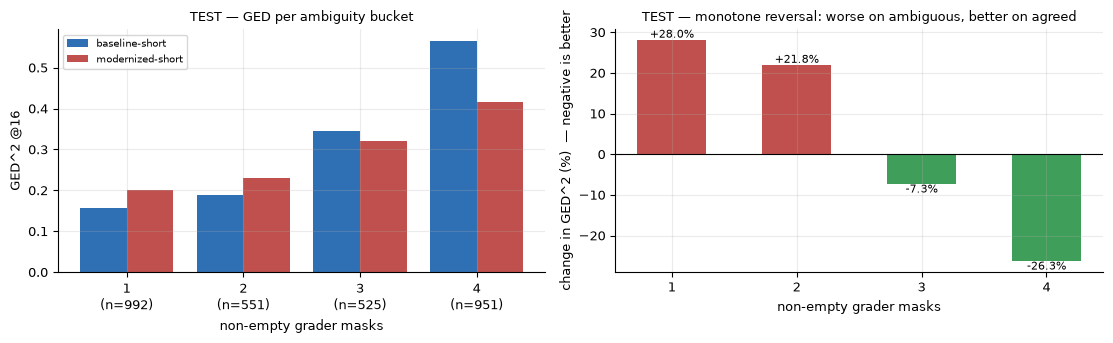

TEST split — GED^2 @16 by ambiguity bucket
bucket  n    baseline-short  modernized-short  change   %     
------  ---  --------------  ----------------  -------  ------
1       992          0.1567            0.2005  +0.0439  +28.0%
2       551          0.1898            0.2313  +0.0415  +21.8%
3       525          0.3457            0.3203  -0.0254   -7.3%
4       951          0.5654            0.4167  -0.1487  -26.3%

change in GED^2 (%): 28.0% -> -26.3% across buckets, monotonically falling (steps -6.2, -29.2, -18.9)

The sign REVERSES across the buckets: Phase 2 hurts where lesion EXISTENCE is in doubt
and helps where all four graders agree something is there. The single bucket 4
contributes -0.0468 to an aggregate change of -0.0293 -- more than the
whole aggregate gain. An ordered structure across four independent populations,
predicted by the sharpening account and then observed on a split that informed no
decision, is much stronger evidence than a single aggregate that could move 

In [12]:
buckets = sorted(comp["variants"][arms[0]]["per_bucket"], key=int)
B = {a: comp["variants"][a]["per_bucket"] for a in arms}
b0 = [val(B[arms[0]][k], f"ged@{N}") for k in buckets]
b1 = [val(B[arms[1]][k], f"ged@{N}") for k in buckets]
pct = [100.0 * (y - x) / x for x, y in zip(b0, b1)]
npatch = [B[arms[0]][k]["n_patches"] for k in buckets]

fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.5))
x = np.arange(len(buckets))
axes[0].bar(x - 0.2, b0, 0.4, label=arms[0], color=CLR["baseline"])
axes[0].bar(x + 0.2, b1, 0.4, label=arms[1], color=CLR["modernized"])
axes[0].set_xticks(x); axes[0].set_xticklabels([f"{k}\n(n={n})" for k, n in zip(buckets, npatch)])
axes[0].set_xlabel("non-empty grader masks"); axes[0].set_ylabel(f"GED^2 @{N}")
axes[0].set_title("TEST — GED per ambiguity bucket"); axes[0].legend(fontsize=7.5)

colours = [CLR["modernized"] if p > 0 else CLR["oracle"] for p in pct]
axes[1].bar(x, pct, 0.55, color=colours)
axes[1].axhline(0, color="k", lw=0.8)
for xi, p in zip(x, pct):
    axes[1].annotate(f"{p:+.1f}%", (xi, p), ha="center",
                     va="bottom" if p > 0 else "top", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(buckets)
axes[1].set_xlabel("non-empty grader masks")
axes[1].set_ylabel("change in GED^2 (%)  — negative is better")
axes[1].set_title("TEST — monotone reversal: worse on ambiguous, better on agreed")
fig.tight_layout(); plt.show()

table(["bucket", "n", arms[0], arms[1], "change", "%"],
      [[k, f"{n:,}", f"{x0:.4f}", f"{x1:.4f}", f"{x1 - x0:+.4f}", f"{p:+.1f}%"]
       for k, n, x0, x1, p in zip(buckets, npatch, b0, b1, pct)],
      title=f"TEST split — GED^2 @{N} by ambiguity bucket")

best = min(range(len(buckets)), key=lambda i: pct[i])
print()
print(describe_monotonicity(pct, "change in GED^2 (%)"))
print(f"\nThe sign REVERSES across the buckets: Phase 2 hurts where lesion EXISTENCE is "
      f"in doubt\nand helps where all four graders agree something is there. The single "
      f"bucket {buckets[best]}\ncontributes "
      f"{(b1[best] - b0[best]) * npatch[best] / sum(npatch):+.4f} to an aggregate change "
      f"of {g1 - g0:+.4f} -- more than the\nwhole aggregate gain. An ordered structure "
      f"across four independent populations,\npredicted by the sharpening account and "
      f"then observed on a split that informed no\ndecision, is much stronger evidence "
      f"than a single aggregate that could move for many\nreasons.")

### Qualitative: the same patches under both arms

Three cases, chosen **mechanically** — see §4 for the rule and the audit trail. Left block
is `baseline-short` (axis-aligned), right block is `modernized-short` (full covariance),
16 prior samples each, same patch, same seed.

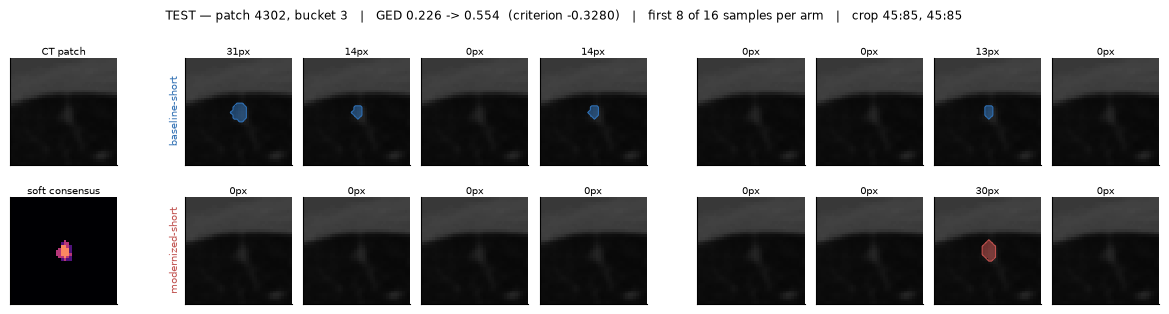

  a0: non-empty samples  baseline-short 7/16, modernized-short 3/16   | grader areas [16, 33, 0, 23] px


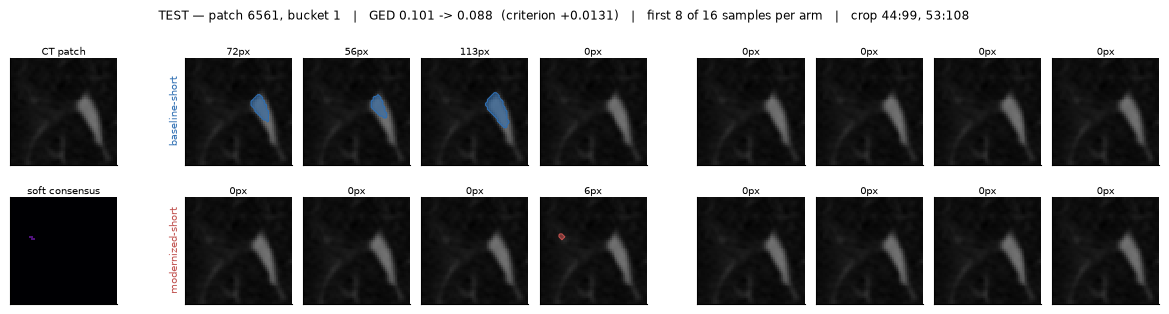

  a1: non-empty samples  baseline-short 4/16, modernized-short 1/16   | grader areas [0, 0, 0, 4] px


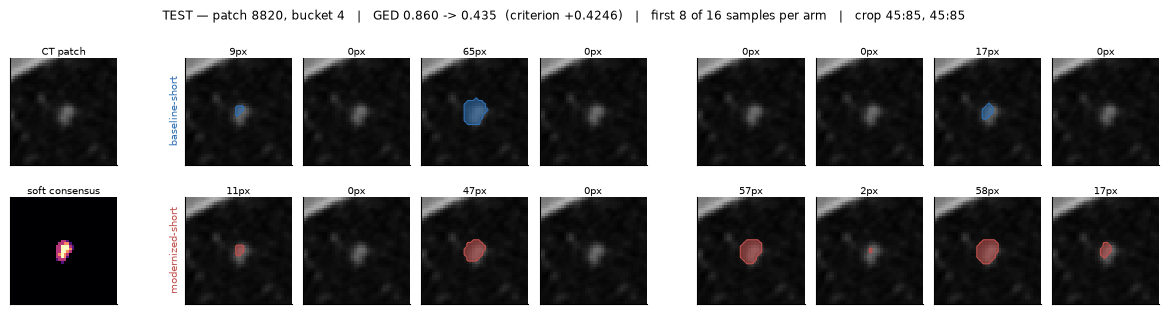

  a2: non-empty samples  baseline-short 5/16, modernized-short 9/16   | grader areas [41, 11, 38, 16] px


In [13]:
for prefix in ("a0", "a1", "a2"):
    counts = phase2_case_figure(SHOW, prefix)
    c = case(prefix)
    print(f"  {prefix}: non-empty samples  "
          + ", ".join(f"{k} {v}/16" for k, v in counts.items())
          + f"   | grader areas {[int(m.sum()) for m in c['masks']]} px")

> **Case `a1` does not carry its figure, and that is being reported rather than worked
> around.** The panel above was rendered and inspected before this was written.
>
> `a1` is the Set A **median** case, selected mechanically. It is a bucket-1 patch whose
> single non-empty grader marked a **4-pixel** lesion. Three things follow, all visible
> above:
>
> - the **soft-consensus tile is effectively black** — a 4-pixel region at level 0.25 is a
>   speck, so the target the two arms are being judged against cannot be seen;
> - the **`modernized-short` row reads as empty** — one of its sixteen samples is
>   non-empty, at 6 px;
> - the `baseline-short` masks *are* visible, but at 56–113 px they are **14–28× the size
>   of the lesion they are supposed to match**, so "which arm is closer" cannot be read off
>   the picture either.
>
> A display guard — *require at least one non-empty sample from each variant before a case
> is eligible* — was specified for the export but **never made it into
> `scripts/export_showcase.py`**. `a1` would have satisfied even that guard (both arms have
> ≥ 1 non-empty sample, which is why its criterion is not exactly zero) while still being
> unreadable, so the guard as specified was too weak.
>
> **The fix is to re-export with a stronger guard** — a minimum non-empty *count* per arm
> and a minimum grader lesion area — and re-run the percentile selection. It is
> deliberately *not* fixed by substituting a different case: the three cases come from a
> rule registered before the test split was examined, and hand-picking a prettier median
> would destroy exactly the property that makes these panels evidence rather than
> illustration. `a0` and `a2` are legible and carry the qualitative comparison in the
> meantime.

---
# 4. Phase 3 — the consensus-selection head  ← the graded contribution

The Probabilistic U-Net deliberately models ambiguity: it produces a *distribution* over
plausible segmentations. But when a downstream decision has to be made, the paper offers no
principled way to choose one. The **oracle** — best-of-16 — needs ground truth and is
therefore unusable at inference.

We add a small head that scores each sampled mask by how well it agrees with the graders,
so the best sample can be selected **without ground truth**. It is trained on a **frozen**
base: the optimizer never sees the base's parameters, and `train()` cannot thaw it, so
attaching the head cannot move any distribution metric. It is trained on **prior** samples,
never posterior ones — posterior samples have seen the ground-truth mask and are almost
always good, so a head trained on those learns to emit a constant high score.

The scoring target is **soft-consensus Dice**, and the head regresses onto it.

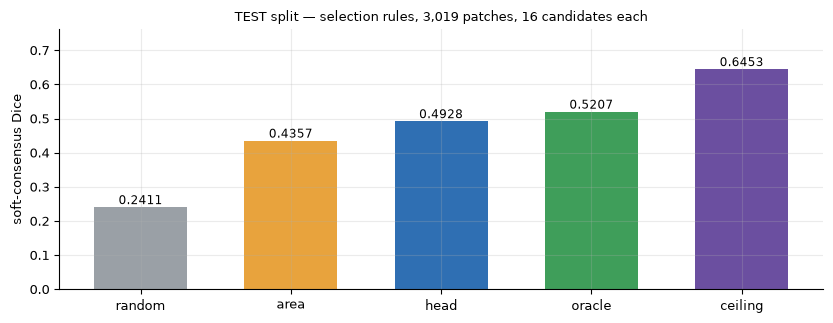

TEST split — Phase 1 base
rule     score   what it is                                            
-------  ------  ------------------------------------------------------
random   0.2411           unselected draw — mean over all 16 candidates
area     0.4357   size prior: sees candidate AREA only, never the image
head     0.4928                                      the selection head
oracle   0.5207  best-of-16 — needs ground truth, unusable at inference
ceiling  0.6453                        best ANY binary mask could score

>>> HEADLINE: the head beats the deterministic largest-candidate rule by +0.0571
>>> soft-consensus Dice, which is 67.2% of the headroom that rule leaves.

The area control reduced to 'pick the largest candidate' on 100.0% of images,
so it really is a deterministic size rule and not a learned scorer in disguise.


In [14]:
SEL = {"Phase 1 base": res("consensus_selection_test.json"),
       "Phase 2 base": res("consensus_selection_modernized_test.json")}
S1 = SEL["Phase 1 base"]["buckets"]["all"]

rules = [("random", "random", "unselected draw — mean over all 16 candidates"),
         ("area", "area_only", "size prior: sees candidate AREA only, never the image"),
         ("head", "head", "the selection head"),
         ("oracle", "oracle", "best-of-16 — needs ground truth, unusable at inference"),
         ("ceiling", "ceiling", "best ANY binary mask could score")]
scores = {label: val(S1, key) for label, key, _ in rules}

fig, ax = plt.subplots(figsize=(8.4, 3.3))
bars = ax.bar([r[0] for r in rules], [scores[r[0]] for r in rules],
              color=[CLR[r[0]] for r in rules], width=0.62)
for b, r in zip(bars, rules):
    ax.annotate(f"{scores[r[0]]:.4f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=8.5)
ax.set_ylabel("soft-consensus Dice"); ax.set_ylim(0, scores["ceiling"] * 1.18)
ax.set_title(f'TEST split — selection rules, {S1["n"]:,} patches, 16 candidates each')
fig.tight_layout(); plt.show()

table(["rule", "score", "what it is"],
      [[lab, f"{scores[lab]:.4f}", note] for lab, _, note in rules],
      title="TEST split — Phase 1 base")

edge = float(S1["head_edge_over_area"])
print(f"\n>>> HEADLINE: the head beats the deterministic largest-candidate rule by "
      f"{edge:+.4f}\n>>> soft-consensus Dice, which is "
      f"{100 * float(S1['head_edge_frac_of_headroom_area_left']):.1f}% of the headroom "
      f"that rule leaves.\n")
print(f"The area control reduced to 'pick the largest candidate' on "
      f"{100 * val(S1, 'area_picks_largest'):.1f}% of images,\nso it really is a "
      f"deterministic size rule and not a learned scorer in disguise.")

### Why *that* denominator, and why both are printed

An earlier draft led with the head's share of the headroom above **random**. That is the
wrong denominator: it credits the head with work a rule that cannot see the image already
does. A predictor seeing only candidate *area* — no image at all — already captures most of
the gap, because with three of four graders empty, "do not pick an empty candidate" is most
of the available gain.

So the headline is the head's edge **over the size prior**, and the fraction is of the
headroom that prior *leaves*.

The two fractions — `e/tot` (of total headroom) and `e/left` (of headroom the area control
left) — move in **opposite directions** across buckets. Both are arithmetically correct and
they support opposite stories, so both are printed and **neither trend is claimed as the
finding**.

On validation each was cleanly monotone. The cell below **measures** whether that still
holds on test rather than repeating the claim, because a per-bucket regularity that
survived one split is exactly the kind of thing that quietly stops being true on another.

TEST split — Phase 1 base, per ambiguity bucket
bucket     n      random  area    head    oracle  ceil    edge     e/tot  e/left  allmt
---------  -----  ------  ------  ------  ------  ------  -------  -----  ------  -----
1 grader     992  0.0735  0.1756  0.2108  0.2384  0.4000  +0.0352  21.4%   56.1%  0.114
2 graders    551  0.1658  0.3490  0.4157  0.4442  0.5833  +0.0666  23.9%   70.0%  0.074
3 graders    525  0.2556  0.5101  0.5838  0.6100  0.7347  +0.0736  20.8%   73.8%  0.057
4 graders    951  0.4515  0.7163  0.7815  0.8101  0.8878  +0.0652  18.2%   69.5%  0.019
all        3,019  0.2411  0.4357  0.4928  0.5207  0.6453  +0.0571  20.4%   67.2%  0.067

edge   = head - area, the head's contribution beyond a size prior
e/tot  = edge as a fraction of TOTAL headroom (oracle - random)
e/left = edge as a fraction of the headroom the AREA CONTROL LEFT (oracle - area)
allmt  = fraction of images where EVERY candidate was empty; those score 0
         under every rule and are a hard cap on 

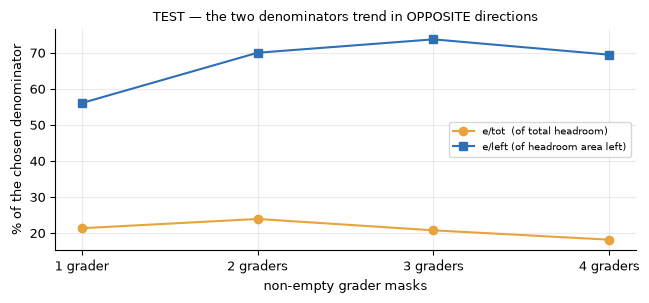

e/tot : 21.4% -> 18.2% across buckets, NOT monotone (steps +2.6, -3.1, -2.6)
e/left: 56.1% -> 69.5% across buckets, NOT monotone (steps +14.0, +3.7, -4.3)

They move in opposite directions end to end, which is the point: the head's edge looks
largest where ambiguity is HIGHEST under one correct denominator and where it is LOWEST
under the other. Neither trend is claimed as the finding. Note also that the clean
per-bucket monotonicity seen on validation did not fully survive the test split -- one
more reason to report both columns and claim neither.


In [15]:
bl = [k for k in SEL["Phase 1 base"]["buckets"] if k != "all"]
rows = []
for k in bl + ["all"]:
    r = SEL["Phase 1 base"]["buckets"][k]
    rows.append([k, f'{r["n"]:,}', f'{val(r, "random"):.4f}', f'{val(r, "area_only"):.4f}',
                 f'{val(r, "head"):.4f}', f'{val(r, "oracle"):.4f}',
                 f'{val(r, "ceiling"):.4f}', f'{float(r["head_edge_over_area"]):+.4f}',
                 f'{100 * float(r["head_edge_frac_of_total_headroom"]):.1f}%',
                 f'{100 * float(r["head_edge_frac_of_headroom_area_left"]):.1f}%',
                 f'{float(r["all_candidates_empty_fraction"]):.3f}'])
table(["bucket", "n", "random", "area", "head", "oracle", "ceil", "edge", "e/tot",
       "e/left", "allmt"], rows,
      title="TEST split — Phase 1 base, per ambiguity bucket",
      note=("\nedge   = head - area, the head's contribution beyond a size prior\n"
            "e/tot  = edge as a fraction of TOTAL headroom (oracle - random)\n"
            "e/left = edge as a fraction of the headroom the AREA CONTROL LEFT "
            "(oracle - area)\n"
            "allmt  = fraction of images where EVERY candidate was empty; those score 0\n"
            "         under every rule and are a hard cap on any selector"))

et = [100 * float(SEL["Phase 1 base"]["buckets"][k]["head_edge_frac_of_total_headroom"])
      for k in bl]
el = [100 * float(SEL["Phase 1 base"]["buckets"][k]["head_edge_frac_of_headroom_area_left"])
      for k in bl]
fig, ax = plt.subplots(figsize=(6.6, 3.1))
ax.plot(range(len(bl)), et, "o-", color=CLR["area"], label="e/tot  (of total headroom)")
ax.plot(range(len(bl)), el, "s-", color=CLR["head"], label="e/left (of headroom area left)")
ax.set_xticks(range(len(bl))); ax.set_xticklabels(bl)
ax.set_xlabel("non-empty grader masks"); ax.set_ylabel("% of the chosen denominator")
ax.set_title("TEST — the two denominators trend in OPPOSITE directions")
ax.legend(fontsize=7.5); fig.tight_layout(); plt.show()
print(describe_monotonicity(et, "e/tot "))
print(describe_monotonicity(el, "e/left"))
print("\nThey move in opposite directions end to end, which is the point: the head's "
      "edge looks\nlargest where ambiguity is HIGHEST under one correct denominator and "
      "where it is LOWEST\nunder the other. Neither trend is claimed as the finding. "
      "Note also that the clean\nper-bucket monotonicity seen on validation did not "
      "fully survive the test split -- one\nmore reason to report both columns and claim "
      "neither.")

### The money figure: what the head actually does

All 16 candidates for one test patch, with the pick of each rule outlined. `oracle` needs
ground truth; `area` and `head` do not.

The tile marked **arbitrary (#0)** is candidate index 0 — an unselected draw, shown for
visual contrast. **It is not the `random` baseline:** the published `random` column is the
*mean* over all 16 candidates, and a single index is not that quantity.

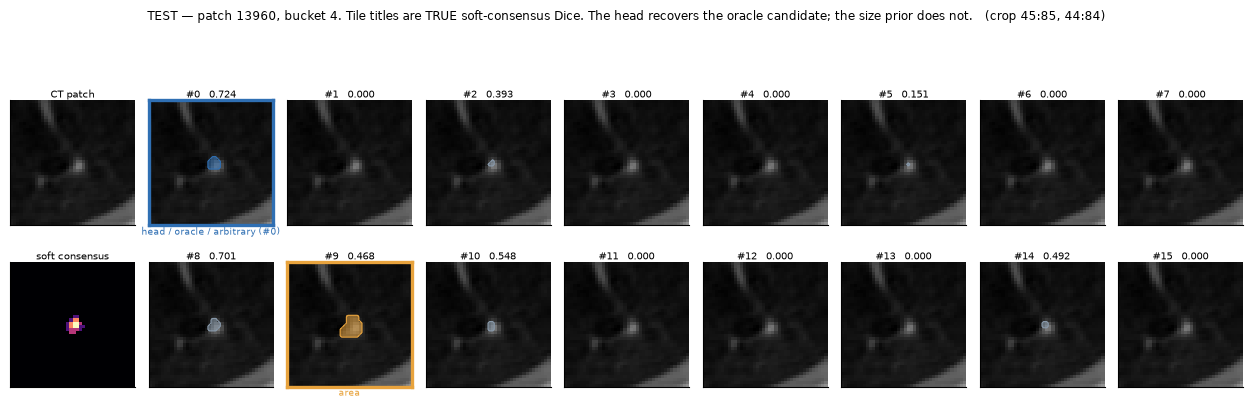

rule              picked  true score  candidate area                            
----------------  ------  ----------  ------------------------------------------
head                  #0      0.7238                                       14 px
area                  #9      0.4683                                       39 px
oracle                #0      0.7238                                       14 px
arbitrary             #0      0.7238                                       14 px
ceiling                —      0.7619                                           —
mean over all 16       —      0.2174  <- this is the published 'random' quantity

NOTE: on this patch the arbitrary draw (#0) HAPPENS to coincide with a rule's pick.
That is not a defect of the figure -- it is what 'no principled way to choose' means:
an unselected draw is sometimes excellent and sometimes empty, and nothing in the
model tells you which. All 16 candidates are shown, so the contrast stays visible.


In [16]:
picks = selection_case_figure(
    SHOW, "b2", "The head recovers the oracle candidate; the size prior does not.")
if picks["arbitrary"] in (picks["head"], picks["area"], picks["oracle"]):
    print("\nNOTE: on this patch the arbitrary draw (#0) HAPPENS to coincide with a "
          "rule's pick.\nThat is not a defect of the figure -- it is what 'no principled "
          "way to choose' means:\nan unselected draw is sometimes excellent and sometimes "
          "empty, and nothing in the\nmodel tells you which. All 16 candidates are shown, "
          "so the contrast stays visible.")

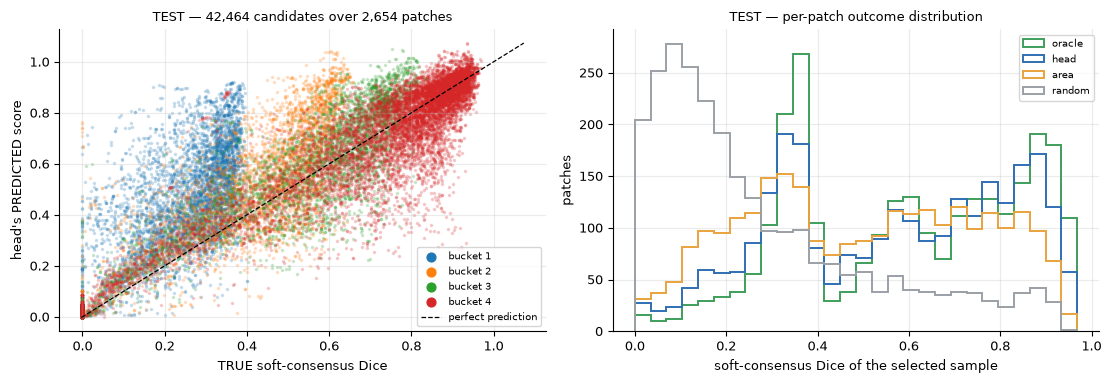

Pearson correlation over all 42,464 candidates: 0.9410
Per-image Spearman (from the results file): head 0.900, area control 0.804 -- so most of
the ranking signal in this task is size, and the head's increment is +0.096.
Degenerate images excluded from Spearman (all candidates tied): 0.121 -- counted, not dropped.


In [17]:
# Set C: every eligible test patch, every candidate. Does the head's score track truth?
pred, true = SHOW["c_pred_scores"], SHOW["c_true_scores"]
nb = int(SHOW["c_n_candidates"])
per_img_bucket = np.repeat(SHOW["c_buckets"], nb)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.9))
ax = axes[0]
for b in np.unique(SHOW["c_buckets"]):
    m = per_img_bucket == b
    ax.scatter(true[m], pred[m], s=2.5, alpha=0.18, label=f"bucket {b}")
lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
ax.plot(lims, lims, "k--", lw=0.9, label="perfect prediction")
ax.set_xlabel("TRUE soft-consensus Dice"); ax.set_ylabel("head's PREDICTED score")
ax.set_title(f"TEST — {len(pred):,} candidates over {len(SHOW['c_buckets']):,} patches")
leg = ax.legend(fontsize=7, markerscale=4); [h.set_alpha(1) for h in leg.legend_handles]

ax = axes[1]
ax.hist([SHOW["c_random_scores"], SHOW["c_area_scores"], SHOW["c_head_scores"],
         SHOW["c_oracle_scores"]], bins=28, stacked=False,
        color=[CLR["random"], CLR["area"], CLR["head"], CLR["oracle"]],
        label=["random", "area", "head", "oracle"], histtype="step", lw=1.4)
ax.set_xlabel("soft-consensus Dice of the selected sample"); ax.set_ylabel("patches")
ax.set_title("TEST — per-patch outcome distribution"); ax.legend(fontsize=7.5)
fig.tight_layout(); plt.show()

rho = np.corrcoef(true, pred)[0, 1]
print(f"Pearson correlation over all {len(pred):,} candidates: {rho:.4f}")
print(f"Per-image Spearman (from the results file): head "
      f"{val(S1, 'head_spearman'):.3f}, area control {val(S1, 'area_spearman'):.3f} "
      f"-- so most of\nthe ranking signal in this task is size, and the head's increment "
      f"is {val(S1, 'head_spearman') - val(S1, 'area_spearman'):+.3f}.")
print(f"Degenerate images excluded from Spearman (all candidates tied): "
      f"{float(S1['head_spearman_excluded_fraction']):.3f} -- counted, not dropped.")

### The failure case, kept deliberately

`b0` is the **5th-percentile** case of the Set B criterion — the patch where the head loses
to the largest-candidate rule by the most. It is in the export because the case rule was
registered before the test split was examined, and a showcase that only shows wins is an
advertisement rather than a result.

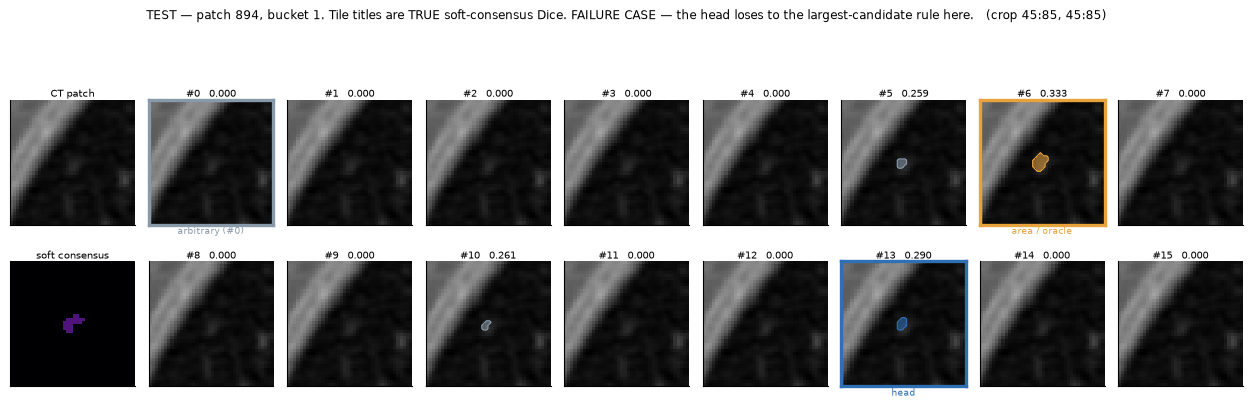

rule              picked  true score  candidate area                            
----------------  ------  ----------  ------------------------------------------
head                 #13      0.2903                                       10 px
area                  #6      0.3333                                       20 px
oracle                #6      0.3333                                       20 px
arbitrary             #0      0.0000                                        0 px
ceiling                —      0.4000                                           —
mean over all 16       —      0.0715  <- this is the published 'random' quantity

The head's pick scores 0.2903 against the area rule's 0.3333: a shortfall of -0.0430,
which is this patch's value of the Set B criterion. Bucket 1, so only one grader saw a
lesion and the achievable ceiling is 0.4000.


In [18]:
selection_case_figure(
    SHOW, "b0", "FAILURE CASE — the head loses to the largest-candidate rule here.")
c = case("b0")
print(f"\nThe head's pick scores {float(c['true_scores'][int(c['pick_head'])]):.4f} "
      f"against the area rule's "
      f"{float(c['true_scores'][int(c['pick_area'])]):.4f}: a shortfall of "
      f"{float(c['criterion']):+.4f},\nwhich is this patch's value of the Set B "
      f"criterion. Bucket {int(c['bucket'])}, so only one grader saw a\nlesion and the "
      f"achievable ceiling is {float(c['ceiling']):.4f}.")

### How the six cases were chosen — auditable, and registered in advance

Two sets of three. For each, a **per-image difference** is computed over every eligible
test patch, and the case nearest the **5th percentile**, the **median** and the **95th
percentile** of that distribution is taken.

Percentile-*nearest*, never `argmin`/`argmax`: single-pixel lesions make the extremes of
both criteria unstable, so the most extreme patch is reliably a metric artifact rather than
an illustrative case.

The record below is printed from the export manifest, so the choice can be audited rather
than trusted.

In [19]:
table(["set", "key", "percentile", "patch", "bucket", "criterion", "value at pctile"],
      [[r["set"], r["key_prefix"], f'{r["percentile"]:.0f}th', r["patch_index"],
        r["bucket"], f'{r["criterion"]:+.4f}', f'{r["percentile_value"]:+.4f}']
       for r in MAN["selection_record"]],
      title="SELECTION RECORD — printed from showcase.npz's manifest")
print()
for k, v in MAN["criteria"].items():
    print(f"  Set {k} criterion: {v}")
print(f"\n  percentiles targeted : {MAN['case_percentiles']}")
print(f"  duplicate selections : {MAN['duplicate_case_positions']}")
print("\nELIGIBILITY GUARDS — applied before the percentiles, counted, never dropped "
      "silently:")
for name, g in MAN["guards"].items():
    print(f"  {name}: " + ", ".join(f"{k}={v}" for k, v in g.items() if k != "note"))
    if "note" in g:
        print(f"      note: {g['note']}")

SELECTION RECORD — printed from showcase.npz's manifest
set  key  percentile  patch  bucket  criterion  value at pctile
---  ---  ----------  -----  ------  ---------  ---------------
A     a0         5th   4302       3    -0.3280          -0.3280
A     a1        50th   6561       1    +0.0131          +0.0131
A     a2        95th   8820       4    +0.4246          +0.4246
B     b0         5th    894       1    -0.0430          -0.0430
B     b1        50th   5537       1    +0.0378          +0.0379
B     b2        95th  13960       4    +0.2555          +0.2557

  Set A criterion: per-image GED at n=16, baseline-short minus modernized-short (positive = modernized better)
  Set B criterion: per-image soft-consensus Dice of the head's pick minus the area control's pick, Phase 1 base (negative = the head lost to the largest-candidate rule)

  percentiles targeted : [5.0, 50.0, 95.0]
  duplicate selections : {'set_a': [], 'set_b': []}

ELIGIBILITY GUARDS — applied before the percentiles, c

In [20]:
# The extension's first claim, verified end-to-end on held-out data rather than argued.
base_ev = res("evaluation_test_baseline.json")["aggregate_over_all_patches"]
head_ev = res("evaluation_test_selection-head.json")["aggregate_over_all_patches"]
keys = [f"ged@{N}", f"ged_ys@{N}", f"ged_ss@{N}", f"ged_yy@{N}",
        f"random_sample_dice@{N}", f"oracle_dice@{N}", f"hungarian_iou@{N}"]

rows = [[k, f"{val(base_ev, k):.6f}", f"{val(head_ev, k):.6f}",
         "identical" if val(base_ev, k) == val(head_ev, k) else "DIFFERS"] for k in keys]
table(["metric", "baseline", "baseline + head", "check"], rows,
      title="TEST split — 'distribution metrics unchanged' (bit-exact comparison)")
print(f"\nAll {sum(val(base_ev, k) == val(head_ev, k) for k in keys)} of {len(keys)} "
      f"distribution metrics are bit-identical with and without the head.")
print("The head is post-hoc on a frozen base, so this is guaranteed by construction -- "
      "and it\nis now also OBSERVED, through the real evaluation entry point, on the "
      "held-out split.")

TEST split — 'distribution metrics unchanged' (bit-exact comparison)
metric                 baseline  baseline + head  check    
---------------------  --------  ---------------  ---------
ged@16                 0.321131         0.321131  identical
ged_ys@16              0.574361         0.574361  identical
ged_ss@16              0.438086         0.438086  identical
ged_yy@16              0.389505         0.389505  identical
random_sample_dice@16  0.462149         0.462149  identical
oracle_dice@16         0.685743         0.685743  identical
hungarian_iou@16       0.763501         0.763501  identical

All 7 of 7 distribution metrics are bit-identical with and without the head.
The head is post-hoc on a frozen base, so this is guaranteed by construction -- and it
is now also OBSERVED, through the real evaluation entry point, on the held-out split.


---
# 5. Composition — the largest finding in the project

Phase 2 improved GED. Phase 3 improves the selected output. A reader who saw only those two
results would predict that stacking them compounds.

**It does not.** The full pipeline — Phase 2 base plus the same selection head — delivers no
better final output than Phase 1 plus that head.

Phase 1 base vs Phase 2 base, both with the same selection head
quantity              TEST P1  TEST P2  TEST delta  VAL P1  VAL P2  VAL delta
--------------------  -------  -------  ----------  ------  ------  ---------
random (the floor)     0.2411   0.2824     +0.0413  0.2349  0.2799    +0.0450
oracle (the ceiling)   0.5207   0.5177     -0.0030  0.5244  0.5215    -0.0029
selectable headroom    0.2796   0.2353     -0.0443  0.2895  0.2416    -0.0479
head-selected output   0.4928   0.4859     -0.0069  0.4940  0.4889    -0.0052


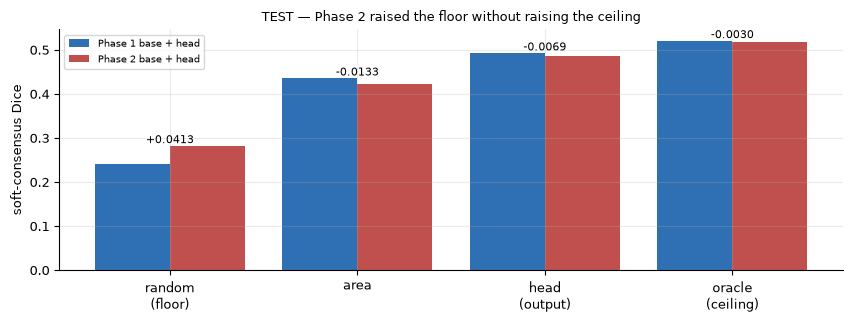


> If the system outputs a SELECTED mask, Phase 2 buys nothing.
> If it outputs a RANDOM sample, Phase 2 buys 17%.

The floor rose +0.0413; the ceiling moved -0.0030. So the total selectable headroom fell
0.2796 -> 0.2353, and a selector capturing a similar share of a
smaller gap lands in essentially the same place from a better start.

This follows directly from the sharpening mechanism of section 3: full covariance
concentrated the sample distribution, which is precisely the operation that improves an
average draw and removes the spread a selector feeds on.


In [21]:
VAL_SEL = {"Phase 1 base": res("consensus_selection_val.json"),
           "Phase 2 base": res("consensus_selection_modernized_val.json")}
A1, A2 = SEL["Phase 1 base"]["buckets"]["all"], SEL["Phase 2 base"]["buckets"]["all"]
V1, V2 = VAL_SEL["Phase 1 base"]["buckets"]["all"], VAL_SEL["Phase 2 base"]["buckets"]["all"]

head_room = lambda b: val(b, "oracle") - val(b, "random")   # noqa: E731

rows = [
    ["random (the floor)", val(A1, "random"), val(A2, "random"),
     val(V1, "random"), val(V2, "random")],
    ["oracle (the ceiling)", val(A1, "oracle"), val(A2, "oracle"),
     val(V1, "oracle"), val(V2, "oracle")],
    ["selectable headroom", head_room(A1), head_room(A2), head_room(V1), head_room(V2)],
    ["head-selected output", val(A1, "head"), val(A2, "head"),
     val(V1, "head"), val(V2, "head")],
]
table(["quantity", "TEST P1", "TEST P2", "TEST delta", "VAL P1", "VAL P2", "VAL delta"],
      [[r[0], f"{r[1]:.4f}", f"{r[2]:.4f}", f"{r[2] - r[1]:+.4f}",
        f"{r[3]:.4f}", f"{r[4]:.4f}", f"{r[4] - r[3]:+.4f}"] for r in rows],
      title="Phase 1 base vs Phase 2 base, both with the same selection head")

fig, ax = plt.subplots(figsize=(8.6, 3.3))
x = np.arange(4)
labels = ["random\n(floor)", "area", "head\n(output)", "oracle\n(ceiling)"]
p1 = [val(A1, k) for k in ("random", "area_only", "head", "oracle")]
p2 = [val(A2, k) for k in ("random", "area_only", "head", "oracle")]
ax.bar(x - 0.2, p1, 0.4, label="Phase 1 base + head", color=CLR["baseline"])
ax.bar(x + 0.2, p2, 0.4, label="Phase 2 base + head", color=CLR["modernized"])
for xi, (a, b) in enumerate(zip(p1, p2)):
    ax.annotate(f"{b - a:+.4f}", (xi, max(a, b)), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("soft-consensus Dice")
ax.set_title("TEST — Phase 2 raised the floor without raising the ceiling")
ax.legend(fontsize=7.5); fig.tight_layout(); plt.show()

gain = (val(A2, "random") - val(A1, "random")) / val(A1, "random")
print(f"""
> If the system outputs a SELECTED mask, Phase 2 buys nothing.
> If it outputs a RANDOM sample, Phase 2 buys {100 * gain:.0f}%.

The floor rose {val(A2, 'random') - val(A1, 'random'):+.4f}; the ceiling moved """
      f"""{val(A2, 'oracle') - val(A1, 'oracle'):+.4f}. So the total selectable headroom fell
{head_room(A1):.4f} -> {head_room(A2):.4f}, and a selector capturing a similar share of a
smaller gap lands in essentially the same place from a better start.

This follows directly from the sharpening mechanism of section 3: full covariance
concentrated the sample distribution, which is precisely the operation that improves an
average draw and removes the spread a selector feeds on.""")

### The defensible claim is the **null**

The head-selected difference between the two bases is smaller than the epoch-to-epoch
oscillation band of the validation monitor the head's checkpoint was chosen on. So:

- **May be claimed:** Phase 2's GED gain **did not translate** into better selected output.
  A null result survives that noise.
- **May *not* be claimed:** that Phase 1 + head **beats** Phase 2 + head. One seed per arm,
  and the difference sits inside the band. **They are not ranked here.**

What buys confidence in the null is that **both splits agree in sign and in magnitude** —
the floor rises, the ceiling does not move, headroom falls, and the selected output ends up
marginally lower on the Phase 2 base, on validation *and* on test, with the ceiling shift
tiny on each. A single split could produce that by chance; two is much harder to attribute
to noise.

Both phases did exactly what they were built to do, measured on their own terms. The
finding is about **composition**, and it required building both and measuring the pipeline
end to end to see it — a report that presented each phase's own metric and stopped would
have implied a combined benefit that does not exist.

---
# 6. Limitations

Stated as measurements wherever a measurement exists.

In [22]:
print("1. ONE SEED PER ARM. Every comparison here is a single run against a single run.\n"
      "   No confidence interval in this notebook is a sampling distribution over seeds.\n")

print("2. THE TEST SPLIT IS HARDER FOR ANY SELECTOR -- so small val->test drops must NOT\n"
      "   be read as generalization failure:")
table(["quantity", "VAL", "TEST", "change"], [
    ["images where EVERY candidate is empty (allmt)",
     f'{float(V1["all_candidates_empty_fraction"]):.3f}',
     f'{float(A1["all_candidates_empty_fraction"]):.3f}',
     f'{float(A1["all_candidates_empty_fraction"]) - float(V1["all_candidates_empty_fraction"]):+.3f}'],
    ["degenerate Spearman exclusions (all candidates tied)",
     f'{float(V1["head_spearman_excluded_fraction"]):.3f}',
     f'{float(A1["head_spearman_excluded_fraction"]):.3f}',
     f'{float(A1["head_spearman_excluded_fraction"]) - float(V1["head_spearman_excluded_fraction"]):+.3f}'],
    ["head-selected output",
     f'{val(V1, "head"):.4f}', f'{val(A1, "head"):.4f}',
     f'{val(A1, "head") - val(V1, "head"):+.4f}'],
])
print("   Images where every candidate is empty score exactly 0 under every rule, so they\n"
      "   cap any selector. Part of every small val->test decline is the split being\n"
      "   harder, not the model generalizing worse. That is a limitation of the BASE\n"
      "   MODEL'S SAMPLER, not of the head.\n")

print("3. DENOMINATOR-DEPENDENCE. See the e/tot vs e/left chart in section 4: the two\n"
      "   correct denominators trend in opposite directions across buckets. Any single\n"
      "   per-bucket trend statement about the head's edge is a statement about the\n"
      "   denominator. Both columns are printed; neither trend is claimed.\n")

print("4. A DIRTY GIT SHA. One checkpoint was produced from a working tree with\n"
      "   uncommitted changes, so its recorded revision does not fully describe the code\n"
      "   that produced it:")
for name, v in MAN["variants"].items():
    if "dirty" in (v["checkpoint_git_revision"] or ""):
        print(f"      {name:28s} {v['checkpoint_git_revision']}")
    if "dirty" in (v["base_git_revision"] or ""):
        print(f"      {name:28s} frozen base {v['base_git_revision']}")

1. ONE SEED PER ARM. Every comparison here is a single run against a single run.
   No confidence interval in this notebook is a sampling distribution over seeds.

2. THE TEST SPLIT IS HARDER FOR ANY SELECTOR -- so small val->test drops must NOT
   be read as generalization failure:
quantity                                              VAL     TEST    change 
----------------------------------------------------  ------  ------  -------
images where EVERY candidate is empty (allmt)          0.048   0.067   +0.019
degenerate Spearman exclusions (all candidates tied)   0.103   0.121   +0.018
head-selected output                                  0.4940  0.4928  -0.0012
   Images where every candidate is empty score exactly 0 under every rule, so they
   cap any selector. Part of every small val->test decline is the split being
   harder, not the model generalizing worse. That is a limitation of the BASE
   MODEL'S SAMPLER, not of the head.

3. DENOMINATOR-DEPENDENCE. See the e/tot vs e/lef

In [23]:
# 5. The aggregate-only restatement of a refutation that TEST weakened.
per_bucket_edge = []
for k in bl:
    e1 = float(SEL["Phase 1 base"]["buckets"][k]["head_edge_over_area"])
    e2 = float(SEL["Phase 2 base"]["buckets"][k]["head_edge_over_area"])
    per_bucket_edge.append((k, e1, e2, e2 - e1))
agg1 = float(A1["head_edge_over_area"]); agg2 = float(A2["head_edge_over_area"])

table(["bucket", "edge, P1 base", "edge, P2 base", "change"],
      [[k, f"{e1:+.4f}", f"{e2:+.4f}", f"{d:+.4f}"] for k, e1, e2, d in per_bucket_edge]
      + [["all", f"{agg1:+.4f}", f"{agg2:+.4f}", f"{agg2 - agg1:+.4f}"]],
      title="5. TEST split — the head's edge over the size prior, both bases")

flat = min(per_bucket_edge, key=lambda r: abs(r[3]))
print(f"""
A prediction registered before the run said the head's edge would SHRINK on the sharpened
Phase 2 base. It GREW ({agg1:+.4f} -> {agg2:+.4f}), and that refutation is recorded as a
refutation rather than a qualified confirmation.

BUT: on validation the edge grew in all four buckets, and that per-bucket claim did NOT
survive the test split -- bucket {flat[0]} moved {flat[3]:+.4f}, which is essentially flat.
ONLY THE AGGREGATE REFUTATION MAY BE RESTATED. Nothing per-bucket.

The mechanism is not "the head got better": the head's own score fell. The edge grew
because the size-only rule degraded faster than the head did on a more concentrated
candidate set.""")

5. TEST split — the head's edge over the size prior, both bases
bucket     edge, P1 base  edge, P2 base  change 
---------  -------------  -------------  -------
1 grader         +0.0352        +0.0395  +0.0043
2 graders        +0.0666        +0.0713  +0.0046
3 graders        +0.0736        +0.0743  +0.0007
4 graders        +0.0652        +0.0780  +0.0128
all              +0.0571        +0.0635  +0.0064

A prediction registered before the run said the head's edge would SHRINK on the sharpened
Phase 2 base. It GREW (+0.0571 -> +0.0635), and that refutation is recorded as a
refutation rather than a qualified confirmation.

BUT: on validation the edge grew in all four buckets, and that per-bucket claim did NOT
survive the test split -- bucket 3 graders moved +0.0007, which is essentially flat.
ONLY THE AGGREGATE REFUTATION MAY BE RESTATED. Nothing per-bucket.

The mechanism is not "the head got better": the head's own score fell. The edge grew
because the size-only rule degraded faster th

In [24]:
# 6. Selection-on-validation optimism -- rendered from DEVIATIONS.md rather than retyped,
#    so the numbers come from the tracked file that owns them.
from IPython.display import Markdown, display

text = (ROOT / "DEVIATIONS.md").read_text().split("\n")
start = next(i for i, ln in enumerate(text) if ln.startswith("## 14."))
end = next((i for i in range(start + 1, len(text)) if text[i].startswith("## ")), len(text))
print("6. SELECTION-ON-VALIDATION OPTIMISM — VAL-MEASURED BY CONSTRUCTION.")
print("   Rendered verbatim from DEVIATIONS.md, entry 14:\n")
display(Markdown("\n".join(text[start:end]).replace("## 14.", "#### DEVIATIONS 14.")))

print(f"The val->test movement quoted there is reproducible from the tracked results "
      f"files:\n  val {val(V1, 'head'):.4f} -> test {val(A1, 'head'):.4f}  "
      f"= {val(A1, 'head') - val(V1, 'head'):+.4f}")
print("\n7. THE PRE-REGISTERED BAND FOR THE HEAD WAS MISCALIBRATED -- also a VAL-side\n"
      "   artifact, and quoted in the entry above. The band was registered before the\n"
      "   size-prior control existed; the control alone scores above the entire band, so\n"
      "   the band was wrong rather than the head over-performing. Reported as the\n"
      "   pre-registration working correctly: it forced the explanation before the result\n"
      "   was written up.")

6. SELECTION-ON-VALIDATION OPTIMISM — VAL-MEASURED BY CONSTRUCTION.
   Rendered verbatim from DEVIATIONS.md, entry 14:



#### DEVIATIONS 14. The head's headline number is the metric its checkpoint was selected on

`configs/extension.yaml` monitors `val/selected_consensus_dice` and keeps the best
checkpoint by it across 30 epochs. **That same metric is then the reported result.** The
number is therefore the maximum of 30 draws of a noisy quantity, not an unbiased estimate of
it -- classic selection-on-validation optimism.

**Why it is set up this way, and why that is still right.** Monitoring the deliverable was a
deliberate Stage 4 choice: a proxy metric can be gamed by a constant predictor, whereas the
selected-sample score cannot (a constant score degenerates to a fixed arbitrary pick and
lands near random). The alternative -- selecting on the Huber loss -- would have been worse,
because a low loss is compatible with zero ranking ability (FINDINGS 4.5). So the setup
stands; the *caveat* is what must be reported.

**Size of the effect -- MEASURED, no longer estimated.**

| quantity | value |
|---|---|
| plateau mean, epochs 10-29 | 0.4897 |
| reported figure (`best.pt`, epoch 28) | 0.4940 |
| **optimism** | **+0.0043** |
| as a fraction of the 0.2895 headroom | **1.5%** |

So the reported number sits **at the top of the noise band**, and the bias is 1.5% of
headroom -- real, small, and worth one sentence rather than a caveat paragraph. It does not
explain why 0.4940 was far above the pre-registered 0.30-0.36 band; that turned out to be a
miscalibrated band rather than an inflated result (FINDINGS 4.5).

**The estimate was CONSERVATIVE -- the test split settled it.** The +0.0043 figure above is
the optimism *estimated* from the validation curve (best minus plateau mean). The **measured**
val-to-test movement is **0.0012** (0.4940 → 0.4928), roughly a third of it. So selecting the
checkpoint on validation cost less than the within-run curve suggested it might, and the
validation figure was a closer estimate of held-out performance than this entry originally
implied.

Report the **test** figure (0.4928) as the headline and this entry as the reason validation
numbers are development record rather than results. The estimate erring on the pessimistic
side is the right direction for a caveat to err in.

**Budget was sufficient.** The monitor **plateaus by epoch 10** and thereafter oscillates in
a band of roughly 0.008, so the 30-epoch budget was not the binding constraint.
`extension.yaml` pre-registered the reading for exactly this outcome -- "if it plateaus by
15, that is a legitimate finding about how little capacity this task needs". It plateaued by
10, and `best.pt` came from epoch 28, i.e. from within the plateau rather than from a still-
rising curve.

**The clean figure, and it must be run exactly once.** The **test** split (3019 patches) has
never been touched by checkpoint selection, so the test-split
`selected_consensus_dice` is the unbiased number. Run it **once**, at the end, and report it
as the headline with the validation figure beside it:

```
python scripts/consensus_headroom.py \
    --head-checkpoint runs/selection-head/checkpoints/best.pt --split test \
    --out results/consensus_selection_test.json
```

CLAUDE.md's rule holds: test is touched once. Do not iterate against it, and do not re-run
it after a change to the head -- that would convert it into a second validation split and
lose the only clean number the project has.

---


The val->test movement quoted there is reproducible from the tracked results files:
  val 0.4940 -> test 0.4928  = -0.0012

7. THE PRE-REGISTERED BAND FOR THE HEAD WAS MISCALIBRATED -- also a VAL-side
   artifact, and quoted in the entry above. The band was registered before the
   size-prior control existed; the control alone scores above the entire band, so
   the band was wrong rather than the head over-performing. Reported as the
   pre-registration working correctly: it forced the explanation before the result
   was written up.


---
# 7. Tier 2 — the executability demo

> # ⚠️ NOTHING BELOW THIS LINE IS A RESULT
>
> This section trains a **deliberately undersized** model for a few minutes to show that
> the pipeline runs end-to-end inside Colab. Specifically:
>
> - it trains on a **few hundred** patches, against the full training split the reported
>   models used — the exact counts are printed by the next cell, from the file itself;
> - it runs a budget orders of magnitude below the paper's;
> - **its metrics appear nowhere in this notebook, in the report, or in `results/`**;
> - **its numbers are expected to be poor**, and a poor number here says nothing about
>   anything above;
> - **the weights are discarded** at the end of the section.
>
> Every result in sections 0–6 comes from the full-length runs documented in §0, which were
> trained on a local RTX 3070 Ti over days and cannot run in a Colab session.

**Two known issues, noted rather than silently worked around.**

1. **`log.tensorboard` must be `false` for this config.** A subset-based run crashes in
   `Trainer._log_panel`: it passes the diagnostic panel indices to `panel_batch`, which
   documents its argument as *full-dataset* numbering, but on a subset export those indices
   are **subset rows**. The two numberings coincide on the full dataset, so this latent bug
   only surfaces on a subset — and this demo is the first configuration in the project to
   train on one. The one-line fix is written out in `configs/colab_demo.yaml`; it is not
   applied because it changes shared training code that all three phases run through. The
   diagnostics themselves still run; only the TensorBoard writer and its panel image are
   given up.

2. **The validation curve wobbles.** Validation is 32 patches over 16 steps per epoch, so
   epoch-to-epoch movement is dominated by sampling noise. The training loss is plotted
   **including its epoch-1 value**, so the initial order-of-magnitude drop dominates the
   axis and the later wobble reads as what it is.

In [25]:
# Tier 2, step 1: load the tracked demo subset through the REAL loader. No download.
import yaml
from probunet.data.lidc import LidcArrays, build_data
from probunet.data.splits import load_split
from probunet.training.config import ExperimentConfig

DEMO_CFG = ROOT / "configs" / "colab_demo.yaml"
cfg = ExperimentConfig.from_yaml(DEMO_CFG)
arrays = LidcArrays.load(cfg.data.npz_path)
split = load_split(cfg.data.split_path, expected_n_patches=len(arrays))
data = build_data(cfg.data)

table(["field", "value"], [
    ["subset file", str(cfg.data.npz_path)],
    ["size on disk", f"{Path(cfg.data.npz_path).stat().st_size / 1024**2:.2f} MiB"],
    ["patches", f"{len(arrays):,}"],
    ["is a subset export", str(arrays.is_subset)],
    ["demo split file", str(cfg.data.split_path)],
    ["train / val / test", f'{len(data.datasets["train"])} / '
                          f'{len(data.datasets["val"])} / {len(data.datasets["test"])}'],
    ["budget", f"{cfg.train.iterations} iterations, batch {cfg.data.batch_size}"],
    ["augmentation", str(cfg.data.augmentation.enabled)],
    ["tensorboard", str(cfg.log.tensorboard) + "   <- see known issue 1 above"],
], title="TIER 2 — the demo subset, loaded through the real dataset class")

counts = arrays.nonempty_counts()
print("\nambiguity buckets in the subset: "
      + ", ".join(f"{b}: {int((counts == b).sum())}" for b in (1, 2, 3, 4)))
print(f"test split in the demo file    : {len(data.datasets['test'])} patches -- EMPTY by "
      f"construction.\n  No test patch was drawn into this subset, and that was asserted "
      f"on the final\n  selected indices at export time, not on the candidate pool.")

TIER 2 — the demo subset, loaded through the real dataset class
field               value                             
------------------  ----------------------------------
subset file         data/processed/lidc_colab_demo.npz
size on disk                                  8.32 MiB
patches                                            288
is a subset export                                True
demo split file      data/splits/colab_demo_split.json
train / val / test                        256 / 32 / 0
budget                         128 iterations, batch 4
augmentation                                      True
tensorboard         False   <- see known issue 1 above

ambiguity buckets in the subset: 1: 72, 2: 72, 3: 72, 4: 72
test split in the demo file    : 0 patches -- EMPTY by construction.
  No test patch was drawn into this subset, and that was asserted on the final
  selected indices at export time, not on the candidate pool.


In [26]:
# Tier 2, step 2: train, through the real entry point, on whatever device Colab gives.
import subprocess, sys, time

t0 = time.time()
proc = subprocess.run(
    [sys.executable, "scripts/train.py", "--config", str(DEMO_CFG)],
    cwd=ROOT, capture_output=True, text=True,
)
elapsed = time.time() - t0
tail = [ln for ln in proc.stdout.splitlines() + proc.stderr.splitlines()
        if "epoch" in ln or "device" in ln or "budget" in ln or "finished" in ln]
print("\n".join(tail[-14:]))
print(f"\nreturn code {proc.returncode} — wall clock {elapsed:.0f} s")
if proc.returncode != 0:
    print("\n--- stderr tail ---\n" + "\n".join(proc.stderr.splitlines()[-25:]))
assert proc.returncode == 0, "the demo training run failed; see the stderr tail above"

11:25:44 INFO    probunet.training.trainer | new best val/total=586.74749 at epoch 3
11:25:46 INFO    probunet.training.trainer | epoch 4/8 train/total=608.6010 train/ce=586.8633 train/kl=21.7377 val/total=548.0304 diag/gap_total=-60.5705 eta=5.2 s
11:25:47 INFO    probunet.training.checkpoint | wrote checkpoint runs/colab_demo/checkpoints/last.pt (epoch 4, step 64)
11:25:47 INFO    probunet.training.checkpoint | wrote checkpoint runs/colab_demo/checkpoints/best.pt (epoch 4, step 64)
11:25:47 INFO    probunet.training.trainer | new best val/total=548.03043 at epoch 4
11:25:49 INFO    probunet.training.trainer | epoch 5/8 train/total=632.9933 train/ce=625.1581 train/kl=7.8353 val/total=823.3324 diag/gap_total=190.3390 eta=3.9 s
11:25:49 INFO    probunet.training.checkpoint | wrote checkpoint runs/colab_demo/checkpoints/last.pt (epoch 5, step 80)
11:25:50 INFO    probunet.training.trainer | epoch 6/8 train/total=978.7916 train/ce=968.1140 train/kl=10.6776 val/total=632.0145 diag/gap_tota

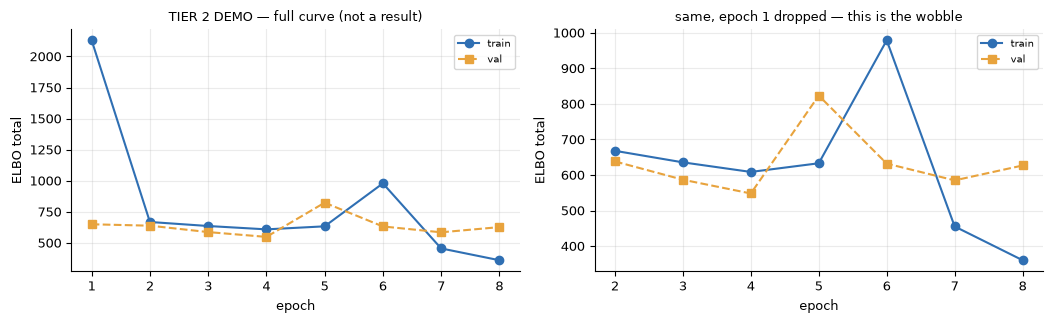

train ELBO  epoch 1    2129.8  ->  epoch 8.0    360.3   (-83.1%)
monitored   val/total best 548.0304 after 8 epochs / 128 steps

The left panel is the message of this section: the curve descends by an order of
magnitude. The right panel shows why the tail wobbles -- validation is 32 patches
over 16 steps per epoch, so epoch-to-epoch movement there is sampling noise, not
training dynamics. Neither number is reported anywhere.


In [27]:
# Tier 2, step 3: the loss curve. Train loss INCLUDING epoch 1, so the initial drop
# dominates and the later wobble reads as the sampling noise it is.
summary = json.loads((ROOT / cfg.run.out_dir / cfg.run.name / "summary.json").read_text())
hist = summary["history"]
ep = [h["epoch"] + 1 for h in hist]
tr = [h["train/total"] for h in hist]
va = [h.get("val/total") for h in hist]

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.3))
axes[0].plot(ep, tr, "o-", color=CLR["baseline"], label="train")
axes[0].plot(ep, va, "s--", color=CLR["area"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("ELBO total")
axes[0].set_title("TIER 2 DEMO — full curve (not a result)"); axes[0].legend(fontsize=7.5)

axes[1].plot(ep[1:], tr[1:], "o-", color=CLR["baseline"], label="train")
axes[1].plot(ep[1:], va[1:], "s--", color=CLR["area"], label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("ELBO total")
axes[1].set_title("same, epoch 1 dropped — this is the wobble")
axes[1].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

print(f"train ELBO  epoch 1 {tr[0]:>9.1f}  ->  epoch {ep[-1]} {tr[-1]:>8.1f}   "
      f"({100 * (tr[-1] - tr[0]) / tr[0]:+.1f}%)")
print(f"monitored   {summary['monitor']} best {summary['best_metric']:.4f} "
      f"after {summary['epochs']} epochs / {summary['global_step']} steps")
print("\nThe left panel is the message of this section: the curve descends by an order of\n"
      "magnitude. The right panel shows why the tail wobbles -- validation is 32 patches\n"
      "over 16 steps per epoch, so epoch-to-epoch movement there is sampling noise, not\n"
      "training dynamics. Neither number is reported anywhere.")

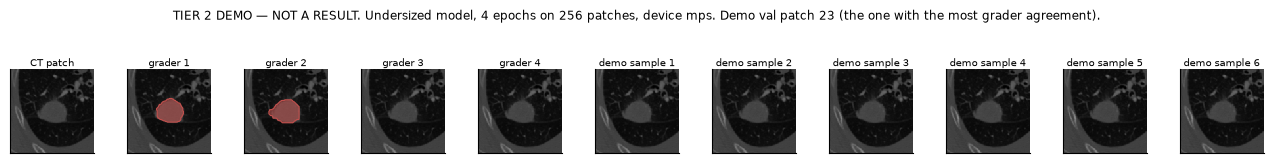

non-empty demo samples: 0 of 6
An undersized model trained for a few minutes will often emit mostly-empty masks:
background pixels vastly outnumber lesion pixels in this data, so the background prior
is what a short run learns first. That is expected here and says nothing about
sections 0-6.

WEIGHTS DISCARDED: removed /Users/ranweisberg/PycharmProjects/Medical Images Analysis with Deep Learning/prob-unet-consensus-selection/runs/colab_demo
Nothing from Tier 2 is retained, reported, or committed.


In [28]:
# Tier 2, step 4: draw a few samples from the demo model, then discard the weights.
import shutil

import torch
from probunet.evaluation.sampling import draw_prior_samples
from probunet.model.prob_unet import ProbUNet
from probunet.training.checkpoint import load_checkpoint
from probunet.utils.runtime import select_device

device = select_device(cfg.run.device)
model = ProbUNet(cfg.model).to(device)
ckpt_dir = ROOT / cfg.run.out_dir / cfg.run.name / "checkpoints"
state = load_checkpoint(ckpt_dir / "best.pt", model=model, map_location=device,
                        restore_rng=False)
model.eval()

# The val patch with the most grader agreement, so the panel has something to show at
# all. Stated rather than silent: a short run emits mostly-empty masks, and picking the
# emptiest patch would make that look worse than it is without being more informative.
val_batch = next(iter(torch.utils.data.DataLoader(
    data.datasets["val"], batch_size=len(data.datasets["val"]), shuffle=False)))
pick = int(val_batch["masks"].flatten(1).sum(1).argmax())
image = val_batch["image"][pick:pick + 1].to(device)
masks = val_batch["masks"][pick:pick + 1]
samples = draw_prior_samples(model, image, 6, torch.Generator().manual_seed(2018))
img = image[0, 0].cpu().numpy(); smp = samples[0].cpu().numpy()

fig, axes = plt.subplots(1, 11, figsize=(13.0, 1.6))
panel(axes[0], img, title="CT patch")
for i in range(4):
    panel(axes[1 + i], img, masks[0, i].numpy(), colour=CLR["grader"],
          title=f"grader {i + 1}")
for i in range(6):
    panel(axes[5 + i], img, smp[i], colour=CLR["head"], title=f"demo sample {i + 1}")
fig.suptitle(f"TIER 2 DEMO — NOT A RESULT. Undersized model, {state.epoch} epochs on "
             f"{len(data.datasets['train'])} patches, device {device}. "
             f"Demo val patch {pick} (the one with the most grader agreement).",
             fontsize=8.5)
fig.tight_layout(rect=(0, 0, 1, 0.86)); plt.show()

print(f"non-empty demo samples: {int((smp.reshape(6, -1).sum(1) > 0).sum())} of 6")
print("An undersized model trained for a few minutes will often emit mostly-empty "
      "masks:\nbackground pixels vastly outnumber lesion pixels in this data, so the "
      "background prior\nis what a short run learns first. That is expected here and "
      "says nothing about\nsections 0-6.")

del model
shutil.rmtree(ROOT / cfg.run.out_dir / cfg.run.name, ignore_errors=True)
print(f"\nWEIGHTS DISCARDED: removed {ROOT / cfg.run.out_dir / cfg.run.name}")
print("Nothing from Tier 2 is retained, reported, or committed.")

---
# 8. Test suite

The library ships a pytest suite that runs on CPU with no accelerator and no full dataset.

**One test is deselected**, with `-m "not version_sensitive"`:
`test_phase1_latent_path_is_unchanged` pins the Phase 1 latent path to **exact float
values**, which is precisely its job — it is what guarantees the Phase 2 refactor was
numerically inert. That also ties it to the NumPy and torch build it was recorded under, so
it fails on Colab's build through no fault of the code. The marker is registered in
`pyproject.toml` and the deselection is stated here rather than hidden.

**Tests that need the full 450 MB `lidc.npz` skip cleanly** when it is absent, which it is
in Colab. The skip count below will therefore be higher here than on the training machine.

In [29]:
import subprocess, sys

proc = subprocess.run(
    [sys.executable, "-m", "pytest", "-m", "not version_sensitive", "-q", "--no-header",
     "--color=no", "-p", "no:cacheprovider", "-rs"],
    cwd=ROOT, capture_output=True, text=True,
)
lines = [ln for ln in proc.stdout.splitlines()
         if ln.startswith(("SKIPPED", "FAILED", "ERROR")) or " passed" in ln
         or " failed" in ln or " error" in ln]
print("\n".join(lines) or proc.stdout[-2000:])
print(f"\nreturn code {proc.returncode}  "
      f"({'PASS' if proc.returncode == 0 else 'FAIL'})")
print("\nSKIPPED entries are environment-dependent and skip CLEANLY rather than "
      "failing: tests\nthat need a CUDA device, and tests that need the full 450 MB "
      "lidc.npz, which is not in\nthe repository. Expect more skips on Colab than on the "
      "machine that trained the models.\nThe one DESELECTED test is the bitwise-loss "
      "fingerprint described above.")

SKIPPED [1] tests/test_training.py:1381: no CUDA device available
541 passed, 1 skipped, 1 deselected in 41.51s

return code 0  (PASS)

SKIPPED entries are environment-dependent and skip CLEANLY rather than failing: tests
that need a CUDA device, and tests that need the full 450 MB lidc.npz, which is not in
the repository. Expect more skips on Colab than on the machine that trained the models.
The one DESELECTED test is the bitwise-loss fingerprint described above.


---
## Closing

**What this notebook is.** Sections 0–6 render recorded predictions from the full-length
runs; section 7 demonstrates that the same code trains end-to-end inside Colab; section 8
runs the tests. No number above section 7 was computed here — each one was loaded from a
tracked `results/*.json` or from `data/processed/showcase.npz`, and the export that
produced those arrays verified them against the published files with no tolerance.

**The three findings the project would lead with.**

1. **Phase 2's outcome was confirmed and its mechanism refuted.** Full covariance improved
   GED by close to the figure independently published for the same change on the same data,
   but it did so by **sharpening** the sample distribution rather than broadening it — and
   sharpening runs against the stated purpose of the Probabilistic U-Net, which exists to
   represent ambiguity. The per-bucket reversal is monotone in ambiguity and reproduced on
   held-out data.

2. **The selection head works, and its honest measure is its edge over a size prior** — not
   over a random draw. It captures about two thirds of the headroom that a deterministic
   largest-candidate rule leaves, and that fraction is stable across two bases and two
   splits.

3. **The two extensions do not compose.** Phase 2 raised the floor without raising the
   ceiling, so there was less left to select. This is a null result and is reported as one:
   the two pipelines are **not** ranked.

Further detail: `DEVIATIONS.md` (every departure from the paper and the reference code),
`configs/` (the record of what each comparison changed), `results/` (every number above).